<a href="https://colab.research.google.com/github/khanuja74/khanuja74/blob/main/Olympics_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Data Loaded Successfully!

Shape of Dataset: (15433, 11)

Preview:
       City    Year     Sport Discipline           Event  \
0  Montreal  1976.0  Aquatics     Diving  3m springboard   
1  Montreal  1976.0  Aquatics     Diving  3m springboard   
2  Montreal  1976.0  Aquatics     Diving  3m springboard   
3  Montreal  1976.0  Aquatics     Diving  3m springboard   
4  Montreal  1976.0  Aquatics     Diving    10m platform   

                    Athlete Gender Country_Code        Country Event_gender  \
0           KÖHLER, Christa  Women          GDR   East Germany            W   
1       KOSENKOV, Aleksandr    Men          URS   Soviet Union            M   
2      BOGGS, Philip George    Men          USA  United States            M   
3  CAGNOTTO, Giorgio Franco    Men          ITA          Italy            M   
4    WILSON, Deborah Keplar  Women          USA  United States            W   

    Medal  
0  Silver  
1  Bronze  
2    Gold  
3  Silver  
4  Bronze  

Checking for missing v

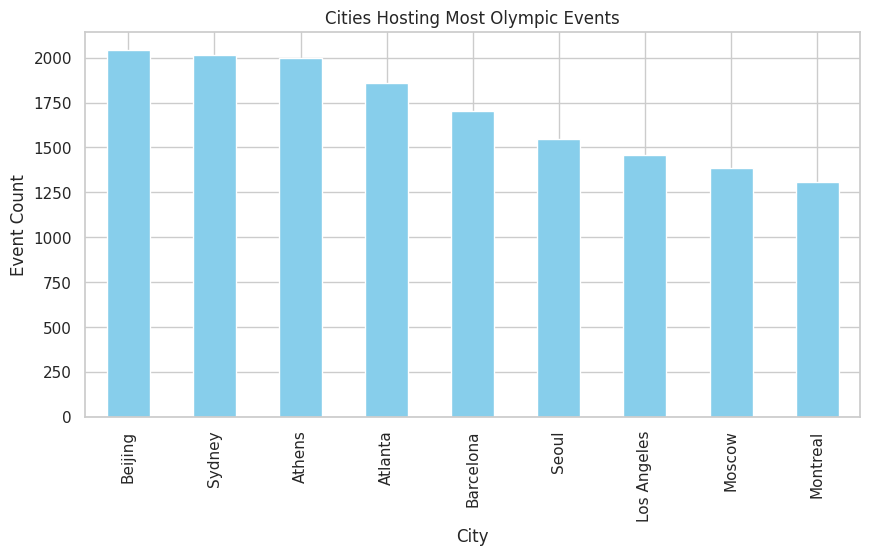

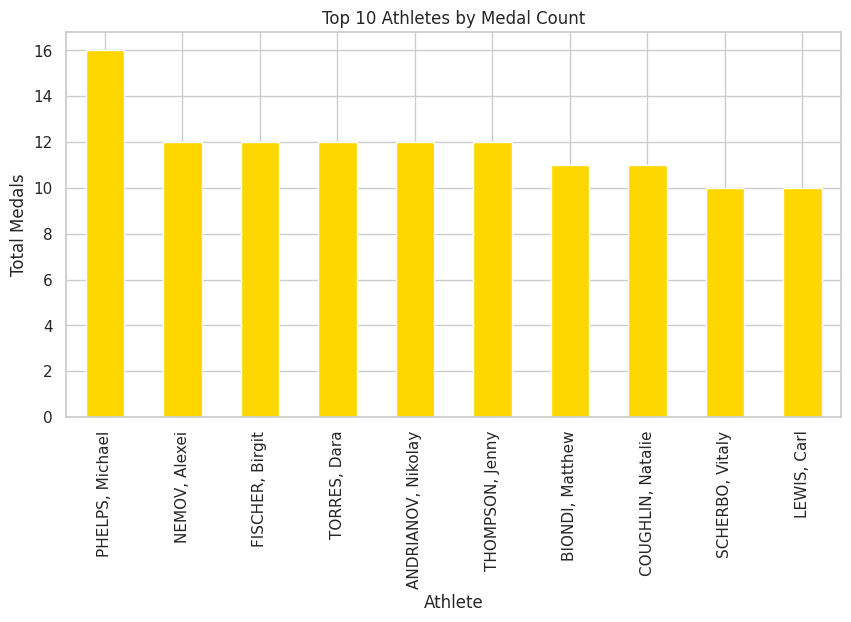


🏆 Top Athlete by Medals: PHELPS, Michael


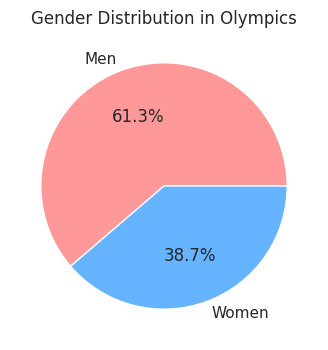

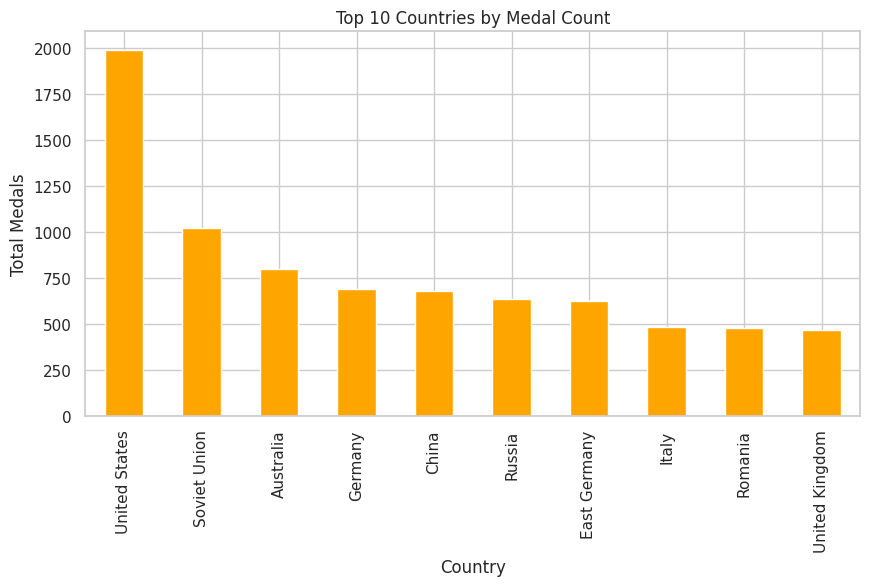

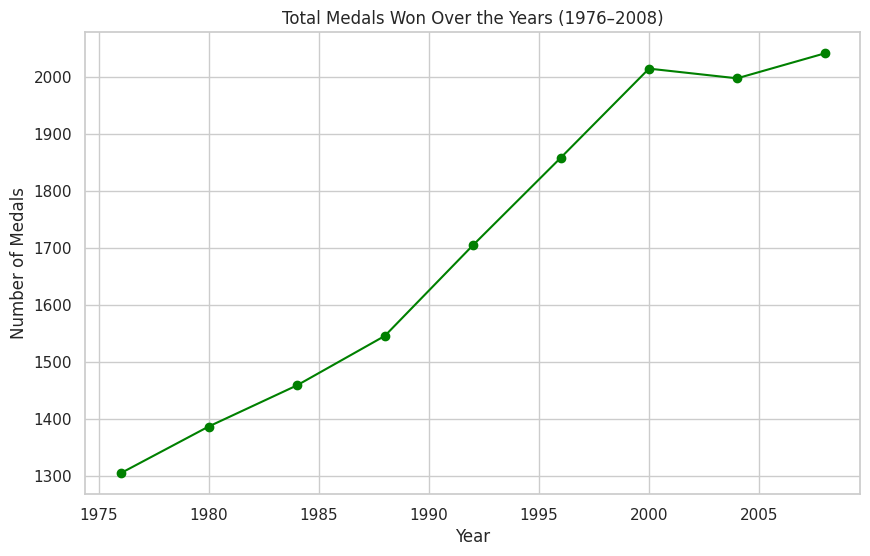


📊 INSIGHTS:
1️⃣ Total number of records: 15316
2️⃣ Number of unique athletes: 11337
3️⃣ Number of unique countries: 127
4️⃣ Most successful athlete: PHELPS, Michael
5️⃣ Country with most medals: United States
6️⃣ Years covered: 1976–2008

💾 Cleaned data saved as 'Cleaned_Olympics_Data.csv'


In [2]:

# 🏅 OLYMPICS DATA ANALYSIS PROJECT (1976–2008)

# Step 1️⃣: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

# Step 2️⃣: Load Dataset
data = pd.read_csv("Summer-Olympic-medals-1976-to-2008.csv", encoding='latin1')
print("✅ Data Loaded Successfully!\n")
print("Shape of Dataset:", data.shape)
print("\nPreview:")
print(data.head())

# Step 3️⃣: Data Cleaning
print("\nChecking for missing values:\n")
print(data.isnull().sum())

data.dropna(how='all', inplace=True)
data['Year'] = data['Year'].astype(int)

if 'Country_Code' in data.columns:
    data.drop('Country_Code', axis=1, inplace=True)
if 'Event_gender' in data.columns:
    data.drop('Event_gender', axis=1, inplace=True)

print("\n✅ Cleaned Data:")
print(data.info())

# Step 4️⃣: Exploratory Data Analysis (EDA)

# 4.1 - Cities that hosted Olympics
city_counts = data[['City', 'Year']].drop_duplicates('Year')
print("\n🏙️ Cities that hosted Olympics (1976–2008):")
print(city_counts)

# 4.2 - Which city hosted the most events
plt.figure(figsize=(10, 5))
data['City'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Cities Hosting Most Olympic Events")
plt.xlabel("City")
plt.ylabel("Event Count")
plt.show()

# 4.3 - Which athlete won the most medals
athlete_medals = data['Athlete'].value_counts().head(10)
plt.figure(figsize=(10, 5))
athlete_medals.plot(kind='bar', color='gold')
plt.title("Top 10 Athletes by Medal Count")
plt.xlabel("Athlete")
plt.ylabel("Total Medals")
plt.show()

print("\n🏆 Top Athlete by Medals:", athlete_medals.index[0])

# 4.4 - Gender distribution
gender_dist = data['Gender'].value_counts()
plt.figure(figsize=(6, 4))
gender_dist.plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title("Gender Distribution in Olympics")
plt.ylabel('')
plt.show()

# 4.5 - Total Medals per Country
country_medals = data['Country'].value_counts().head(10)
plt.figure(figsize=(10, 5))
country_medals.plot(kind='bar', color='orange')
plt.title("Top 10 Countries by Medal Count")
plt.xlabel("Country")
plt.ylabel("Total Medals")
plt.show()

# 4.6 - Trend of Medals Over Years
medals_by_year = data.groupby('Year')['Medal'].count()
plt.figure(figsize=(10, 6))
plt.plot(medals_by_year.index, medals_by_year.values, marker='o', color='green')
plt.title("Total Medals Won Over the Years (1976–2008)")
plt.xlabel("Year")
plt.ylabel("Number of Medals")
plt.grid(True)
plt.show()

# Step 5️⃣: Key Insights
print("\n📊 INSIGHTS:")
print(f"1️⃣ Total number of records: {len(data)}")
print(f"2️⃣ Number of unique athletes: {data['Athlete'].nunique()}")
print(f"3️⃣ Number of unique countries: {data['Country'].nunique()}")
print(f"4️⃣ Most successful athlete: {athlete_medals.index[0]}")
print(f"5️⃣ Country with most medals: {country_medals.index[0]}")
print(f"6️⃣ Years covered: {data['Year'].min()}–{data['Year'].max()}")

# Step 6️⃣: (Optional) Save Cleaned Dataset
data.to_csv("Cleaned_Olympics_Data.csv", index=False)
print("\n💾 Cleaned data saved as 'Cleaned_Olympics_Data.csv'")
